# 🪙 Coin: fair outcomes from biased tosses

This notebook compares a fair coin, a slightly biased coin, and a strongly biased coin. It shows raw tosses (no correction), highest-slot extracted outcomes (bias fixed), and the average number of physical tosses required.

For a coin, toss twice. If one toss is heads and the other tails, output the position of the higher value; otherwise retry. The two positions are symmetric, so the accepted result is fair.

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

FACE_COUNT = 2
NUM_RUNS, TRIALS = 10, 10_000
# Face 2 is progressively more likely.
DICE = {'Fair': [0.5, 0.5], 'Minimal bias': [0.47, 0.53], 'High bias': [0.20, 0.80]}
FACES = np.arange(1, FACE_COUNT + 1)
IDEAL = 1 / FACE_COUNT

## Extractor and simulation

For an n-face source, roll n times. Accept only when the highest face appears in one unique position; that position is the uniform output. Rejected blocks cost n physical launches/tosses.

In [2]:
def roll(weights):
    return random.choices(FACES, weights=weights, k=1)[0]

def extract(weights):
    used = 0
    while True:
        sequence = [roll(weights) for _ in FACES]
        used += FACE_COUNT
        top = max(sequence)
        if sequence.count(top) == 1:
            return sequence.index(top) + 1, used

def probs(values):
    return np.bincount(values, minlength=FACE_COUNT + 1)[1:] / len(values)

def experiment(weights):
    raw_runs, fixed_runs, roll_runs = [], [], []
    for _ in range(NUM_RUNS):
        raw = [roll(weights) for _ in range(TRIALS)]
        extracted = [extract(weights) for _ in range(TRIALS)]
        fixed, used = zip(*extracted)
        raw_runs.append(probs(raw)); fixed_runs.append(probs(fixed)); roll_runs.append(np.mean(used))
    return np.array(raw_runs), np.array(fixed_runs), np.array(roll_runs)

results = {name: experiment(weights) for name, weights in DICE.items()}

## Results and uniformity

Total variation (TV) distance measures the gap from uniform: 0 is perfectly uniform. The extractor should make the fixed TV much smaller than the raw TV.

In [3]:
summary = []
for name, (raw, fixed, rolls) in results.items():
    raw_mean, fixed_mean = raw.mean(0), fixed.mean(0)
    raw_tv = np.abs(raw_mean - IDEAL).sum() / 2
    fixed_tv = np.abs(fixed_mean - IDEAL).sum() / 2
    average_rolls = rolls.mean()
    summary.append((name, raw_tv, fixed_tv, average_rolls, FACE_COUNT / average_rolls))

print(f"{'Bias':<14} {'Raw TV':>8} {'Fixed TV':>9} {'Tosses/outcome':>15} {'Accepted blocks':>16}")
for name, raw_tv, fixed_tv, average_rolls, accepted in summary:
    print(f"{name:<14} {raw_tv:>8.4f} {fixed_tv:>9.4f} {average_rolls:>15.2f} {accepted:>15.1%}")

Bias             Raw TV  Fixed TV  Tosses/outcome  Accepted blocks
Fair             0.0005    0.0016            3.97           50.4%
Minimal bias     0.0316    0.0011            4.04           49.5%
High bias        0.3035    0.0042            6.26           31.9%


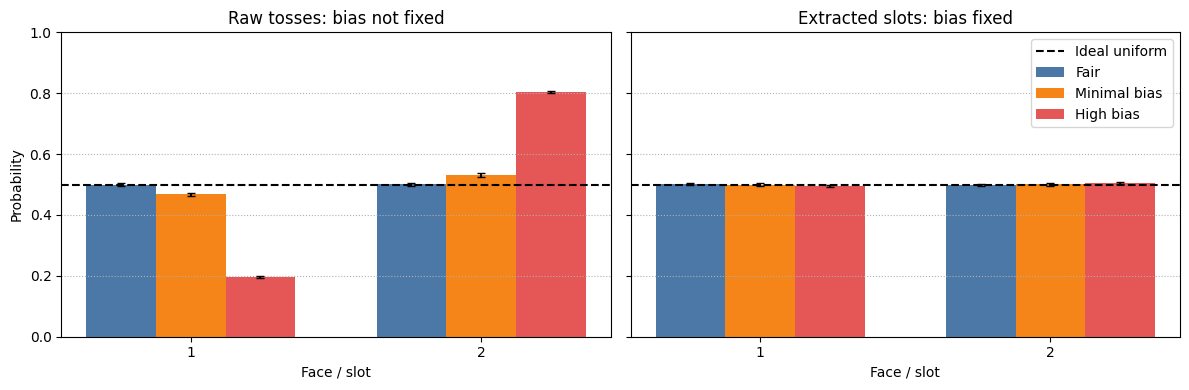

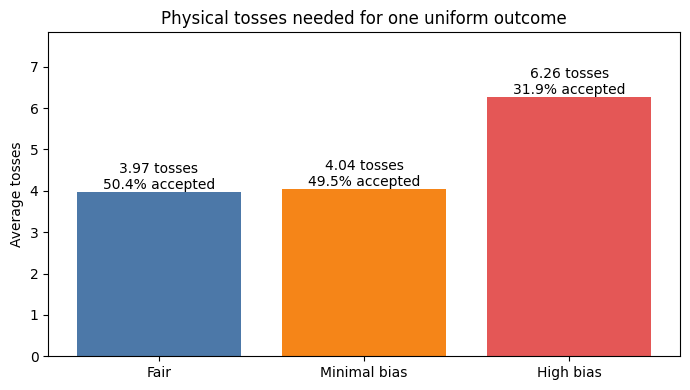

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = ['#4c78a8', '#f58518', '#e45756']; width = .24
for ax, index, title in [(axes[0], 0, 'Raw tosses: bias not fixed'), (axes[1], 1, 'Extracted slots: bias fixed')]:
    for (name, data), offset, color in zip(results.items(), [-width, 0, width], colors):
        runs = data[index]; ax.bar(FACES + offset, runs.mean(0), width, yerr=runs.std(0), capsize=3, label=name, color=color)
    ax.axhline(IDEAL, color='black', linestyle='--', label='Ideal uniform'); ax.set(title=title, xlabel='Face / slot', xticks=FACES, ylim=(0, 1)); ax.grid(axis='y', linestyle=':')
axes[0].set_ylabel('Probability'); axes[1].legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar([x[0] for x in summary], [x[3] for x in summary], color=colors)
plt.title('Physical tosses needed for one uniform outcome'); plt.ylabel('Average tosses')
for bar, item in zip(bars, summary): plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{item[3]:.2f} tosses\n{item[4]:.1%} accepted', ha='center', va='bottom')
plt.ylim(0, max(x[3] for x in summary)*1.25); plt.tight_layout(); plt.show()

## Shannon entropy before and after extraction

Each bar is the mean Shannon entropy across simulation runs. The dashed line is the maximum possible entropy for one coin outcome.

Bias            Raw entropy  Extracted entropy
Fair                0.9999 bits          0.9999 bits
Minimal bias        0.9970 bits          0.9999 bits
High bias           0.7148 bits          0.9999 bits


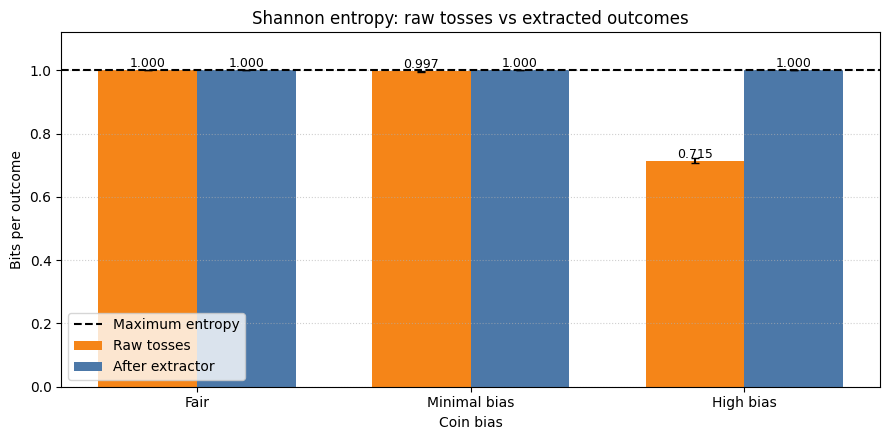

In [5]:
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

entropy_summary = []
for name, (raw_runs, extracted_runs, _) in results.items():
    raw_entropy = np.array([shannon_entropy(probabilities) for probabilities in raw_runs])
    extracted_entropy = np.array([shannon_entropy(probabilities) for probabilities in extracted_runs])
    entropy_summary.append((name, raw_entropy.mean(), extracted_entropy.mean(), raw_entropy.std(), extracted_entropy.std()))

print(f"{'Bias':<14} {'Raw entropy':>12} {'Extracted entropy':>18}")
for name, raw_entropy, extracted_entropy, _, _ in entropy_summary:
    print(f"{name:<14} {raw_entropy:>11.4f} bits {extracted_entropy:>15.4f} bits")

positions = np.arange(len(entropy_summary)); width = 0.36
fig, axis = plt.subplots(figsize=(9, 4.5))
raw_bars = axis.bar(positions - width / 2, [row[1] for row in entropy_summary], width, yerr=[row[3] for row in entropy_summary], capsize=3, label='Raw tosses', color='#f58518')
extracted_bars = axis.bar(positions + width / 2, [row[2] for row in entropy_summary], width, yerr=[row[4] for row in entropy_summary], capsize=3, label='After extractor', color='#4c78a8')
maximum_entropy = np.log2(len(FACES))
axis.axhline(maximum_entropy, color='black', linestyle='--', label='Maximum entropy')
axis.set(title='Shannon entropy: raw tosses vs extracted outcomes', xlabel='Coin bias', ylabel='Bits per outcome', xticks=positions, xticklabels=[row[0] for row in entropy_summary], ylim=(0, maximum_entropy * 1.12))
axis.grid(axis='y', linestyle=':', alpha=0.6); axis.legend()
for bars in (raw_bars, extracted_bars):
    for bar in bars:
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()